# Transfer Learning на ResNet-18: класифікація мурах і бджіл

Тут у тебе фактично **повний приклад transfer learning на ResNet-18 для класифікації мурах і бджіл**. Розберемо його майже «по символах», ніби людина вперше бачить Python.

## Що цей notebook робить у цілому:

```text
1. Завантажує дані
        ↓
2. Готує зображення
        ↓
3. Створює batches
        ↓
4. Завантажує pretrained ResNet-18
        ↓
5. Міняє останній classifier:
   1000 класів → 2 класи
        ↓
6. Навчає модель двома способами:

   A. Fine-tuning
      → змінюємо всі ваги

   B. Feature extractor
      → старі ваги frozen
      → навчаємо тільки новий FC
        ↓
7. Вибирає найкращу модель за validation accuracy
```

# 1. Завантаження репозиторію

Це ще не neural network. Це просто підготовка файлів.

### `!rm -rf deep`

`!` означає: виконай команду **операційної системи**, а не Python.

`rm` = remove. `-r` = видалити також усе всередині папки. `-f` = force.

### `!git clone ...`

Git завантажує копію repository з GitHub. Після цього у Colab з'являється папка `deep/`.

### `%cd deep/тема_6`

`cd` = change directory. Відтепер працюємо усередині папки `deep/тема_6`.

Саме там лежать:

```text
train/
    ants/
    bees/
val/
    ants/
    bees/
```

In [21]:
# Видаляємо стару копію (якщо вже клонували раніше)
!rm -rf deep

# Клонуємо репозиторій з даними та конспектами
!git clone https://github.com/PetraStill/deep.git

# Переходимо в директорію теми 6
%cd deep/тема_6

Cloning into 'deep'...
remote: Enumerating objects: 1687, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 1687 (delta 4), reused 7 (delta 3), pack-reused 1678 (from 3)
Receiving objects: 100% (1687/1687), 82.98 MiB | 34.21 MiB/s, done.
Resolving deltas: 100% (14/14), done.
/content/deep/тема_6/deep/тема_6


# 2. Imports

```python
import torch
```
Підключаємо **PyTorch** — tensors, neural networks, GPU, gradients, training.

```python
import torch.nn as nn
```
`nn` = **neural network**. Готові компоненти: `nn.Linear`, `nn.Conv2d`, `nn.ReLU`, `nn.CrossEntropyLoss`...

`as nn` означає: замість `torch.nn` пишемо коротко `nn`.

```python
import torch.optim as optim
```
`optim` = optimizers (`optim.Adam`, `optim.SGD`). Optimizer змінює ваги моделі на основі gradients.

```python
from torch.optim import lr_scheduler
```
`lr` = learning rate. Scheduler змінює learning rate у процесі навчання.

```python
import numpy as np
```
NumPy працює з числовими масивами. `np` — просто коротка назва.

```python
import torchvision
from torchvision import datasets, models, transforms
```
Доповнення PyTorch для computer vision:
- `datasets` → робота з dataset
- `models` → готові CNN, наприклад ResNet
- `transforms` → обробка зображень

In [23]:
import torch                                    # Основний фреймворк: тензори, GPU, автоградієнти
import torch.nn as nn                           # Шари мережі (Linear, Conv2d), функції втрат
import torch.optim as optim                     # Оптимізатори (SGD, Adam) для оновлення ваг
from torch.optim import lr_scheduler            # Планувальник: зменшує learning rate за розкладом
import torch.backends.cudnn as cudnn            # CUDA бекенд для оптимізації обчислень на GPU
import numpy as np                              # Масиви та математичні операції
import torchvision                              # Інструменти для роботи із зображеннями
from torchvision import datasets, models, transforms  # Датасети, pretrained моделі, аугментації
import matplotlib.pyplot as plt                 # Бібліотека для побудови графіків і відображення зображень
import time                                     # Вимірювання часу тренування
import os                                       # Робота з файловою системою (шляхи, папки)
from PIL import Image                           # Бібліотека для завантаження та обробки зображень
from tempfile import TemporaryDirectory         # Тимчасова папка для збереження чекпоінтів

cudnn.benchmark = True   # Автотюнер CUDA: знаходить найшвидший алгоритм для вашого GPU

plt.ion()                # Інтерактивний режим matplotlib: графіки оновлюються без блокування коду

import warnings
warnings.filterwarnings('ignore')  # Приховати попередження (для чистішого виводу)

# 3. Трансформації зображень

```python
data_transforms = {
    'train': transforms.Compose([...]),
    'val': transforms.Compose([...]),
}
```

Це Python **dictionary** — шафка з двома підписаними коробками:

```text
data_transforms
  "train" → набір трансформацій для training
  "val"   → набір трансформацій для validation
```

## Training трансформації

**`RandomResizedCrop(224)`** — беремо випадковий шматок картинки і приводимо до 224×224. Це **augmentation** — модель бачить одну мураху трохи по-різному кожної епохи.

**`RandomHorizontalFlip()`** — іноді картинка віддзеркалюється горизонтально. Мета: модель не повинна думати, що бджола є бджолою тільки коли дивиться вправо.

**`ToTensor()`** — PIL Image → PyTorch Tensor. Пікселі з `0...255` → `0...1`. Форма стає `[C, H, W]` = `[3, 224, 224]` (3 = RGB channels).

## 4. Normalize

```python
transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
```

Стандартні mean/std ImageNet для R, G, B каналів. Для кожного pixel: `x_norm = (x − mean) / std`

Навіщо? Бо ResNet була pretrained на ImageNet із такою preprocessing. Нові картинки треба подавати **у тому самому форматі**.

## 5. Validation трансформації

```python
'val': transforms.Compose([Resize(256), CenterCrop(224), ...])
```

Тут **немає** випадкового crop і flip:

```text
TRAIN → випадковість дозволена (augmentation)
VAL   → передбачувана обробка (стабільна перевірка)
```

In [24]:
data_transforms = {
    'train': transforms.Compose([          # Ланцюжок трансформацій для тренувальних даних:
        transforms.RandomResizedCrop(224),  # Випадково обрізає і масштабує до 224×224 (аугментація)
        transforms.RandomHorizontalFlip(), # Випадково віддзеркалює горизонтально (аугментація)
        transforms.ToTensor(),             # PIL Image → тензор з діапазоном [0, 1]
        transforms.Normalize(              # Нормалізація за статистиками ImageNet:
            [0.485, 0.456, 0.406],         #   mean для R, G, B каналів
            [0.229, 0.224, 0.225])         #   std для R, G, B каналів
    ]),
    'val': transforms.Compose([            # Ланцюжок трансформацій для валідаційних даних:
        transforms.Resize(256),            # Масштабує менший бік до 256 (без випадковості!)
        transforms.CenterCrop(224),        # Вирізає центральну частину 224×224
        transforms.ToTensor(),             # PIL Image → тензор [0, 1]
        transforms.Normalize(              # Та сама нормалізація ImageNet
            [0.485, 0.456, 0.406],
            [0.229, 0.224, 0.225])
    ]),
}

# 6. Створення Dataset

**`data_dir = '.'`** — `.` означає поточна папка (а ми раніше зробили `%cd deep/тема_6`).

**`ImageFolder`** очікує структуру:

```text
train/
    ants/
        image1.jpg
    bees/
        image3.jpg
```

Назва папки автоматично стає класом: `ants → class 0`, `bees → class 1`.

In [26]:
data_dir = '.'  # Шлях до папки з даними (train/ і val/ лежать прямо в тема_6/)

# Створюємо Dataset для train і val:
# ImageFolder автоматично визначає класи за назвами підпапок (ants/, bees/)
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x),  # шлях: data_dir/train або data_dir/val
                                          data_transforms[x])         # застосовуємо відповідні трансформації
                  for x in ['train', 'val']}

# 7. DataLoader

Dataset каже: «ось усі мої картинки». DataLoader каже: «я буду подавати їх моделі маленькими порціями».

**`batch_size=4`** — модель отримує 4 картинки одночасно. Кожна `3×224×224`, тому batch має форму `[4, 3, 224, 224]` = `[B, C, H, W]`.

**`shuffle=True`** — перед новою епохою картинки перемішуються. Це корисно для training. *(Нюанс: тут shuffle=True задано також для validation — це не катастрофа, але для validation перемішування не потрібне.)*

**`num_workers=4`** — чотири окремі worker-процеси допомагають завантажувати картинки. Це не 4 neural network, а просто 4 помічники, що готують data.

In [27]:
# DataLoader видає дані батчами (пачками) під час тренування:
dataloaders = {x: torch.utils.data.DataLoader(
    image_datasets[x],   # Dataset, з якого брати дані
    batch_size=4,         # По 4 зображення за раз
    shuffle=True,         # Перемішувати дані кожну епоху (для кращого навчання)
    num_workers=4)        # 4 паралельних потоки для завантаження (швидше)
    for x in ['train', 'val']}

# 8. Розмір dataset, назви класів та GPU

**`dataset_sizes`** — наприклад: `train = 244 images`, `val = 153 images`.

**`class_names`** — отримаємо `['ants', 'bees']`.

**`device`** — якщо CUDA GPU доступний → використовуй GPU (`cuda:0` = перший GPU), інакше CPU.

In [28]:
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}  # Кількість зображень
class_names = image_datasets['train'].classes  # Назви класів (з назв папок)

print(dataset_sizes)  # {'train': 244, 'val': 153}
print(class_names)    # ['ants', 'bees']

# Вибираємо пристрій: GPU (якщо доступний) або CPU
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

{'train': 244, 'val': 153}
['ants', 'bees']


# 10. Функція `imshow()`

**`def imshow(inp, title=None)`** — створюємо функцію для відображення зображень.

**`inp.numpy()`** — PyTorch Tensor → NumPy array.

**`.transpose((1, 2, 0))`** — PyTorch тримає image як `[C, H, W]`, а Matplotlib хоче `[H, W, C]`. Наприклад: `[3, 224, 224]` → `[224, 224, 3]`.

**`inp = std * inp + mean`** — це **denormalization** (зворотна нормалізація). До ResNet ми подавали `(x − mean) / std`, а для показу картинки повертаємо: `x = x_norm · std + mean`.

**`np.clip(inp, 0, 1)`** — якщо після обчислень випадково маємо `-0.02`, робимо `0`. Якщо `1.04`, робимо `1`. Гарантує допустимий діапазон для відображення.

In [29]:
def imshow(inp, title=None):
    """Відображає тензор як зображення, скасовуючи нормалізацію ImageNet."""
    inp = inp.numpy().transpose((1, 2, 0))       # Тензор [C,H,W] → масив [H,W,C] для matplotlib
    mean = np.array([0.485, 0.456, 0.406])        # Середнє ImageNet (R, G, B)
    std = np.array([0.229, 0.224, 0.225])          # Стд. відхилення ImageNet (R, G, B)
    inp = std * inp + mean                         # Зворотна нормалізація: повертаємо оригінальні кольори
    inp = np.clip(inp, 0, 1)                       # Обмежуємо [0, 1] — запобігаємо артефактам
    plt.imshow(inp)                                # Відображаємо зображення
    if title is not None:
        plt.title(title)                           # Додаємо заголовок (назви класів)
    plt.pause(0.001)                               # Коротка пауза для оновлення графіка

# 11. Взяти один batch і показати

**`next(iter(dataloaders['train']))`** — розберемо справа наліво:
- `dataloaders['train']` = training DataLoader
- `iter(...)` створює iterator — конвеєр: batch 1, batch 2, batch 3...
- `next(...)` означає: дай мені наступний batch

Тому `inputs` отримує 4 картинки (shape `[4, 3, 224, 224]`), а `classes` — їхні 4 правильні labels (наприклад `[0, 1, 0, 1]`).

**`make_grid(inputs)`** — складає 4 картинки в одну сітку для зручної візуалізації. Це тільки visualization, на training не впливає.

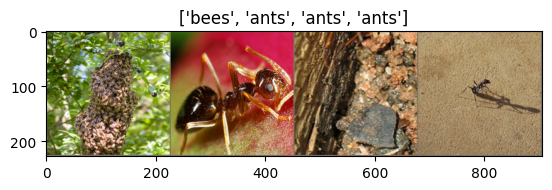

In [30]:
inputs, classes = next(iter(dataloaders['train']))    # Беремо один батч: 4 зображення + 4 мітки
out = torchvision.utils.make_grid(inputs)             # Об'єднуємо 4 зображення в одну сітку
imshow(out, title=[class_names[x] for x in classes])  # Відображаємо з підписами класів

# 13. Найголовніша функція — `train_model`

Функція приймає:
- **model** → яку модель тренувати
- **criterion** → як рахувати помилку
- **optimizer** → як змінювати weights
- **scheduler** → як змінювати learning rate
- **num_epochs** → скільки епох

## Що відбувається всередині:

**`since = time.time()`** — засікаємо час початку training.

**`TemporaryDirectory()`** — створюємо тимчасову папку для збереження найкращих weights. Після закінчення функції папка автоматично видаляється.

**`state_dict()`** — словник `назва параметра → його значення`. Зберігає trained weights і buffers моделі (не всю логіку ResNet, а лише параметри).

**`best_acc = 0.0`** — на початку best validation accuracy = 0%. Пізніше: epoch 1→82%, epoch 2→88%, epoch 3→86% → збережемо weights з epoch 2.

## Epoch loop та дві фази

**`for epoch in range(num_epochs)`** — на кожній епосі модель проходить весь training dataset.

**`for phase in ['train', 'val']`** — кожна епоха має дві фази: TRAIN (модель навчається) → VAL (перевіряємо модель).

**`model.train()`** — training mode. Dropout активний, BatchNorm використовує batch statistics.

**`model.eval()`** — validation mode. Dropout вимкнений, BatchNorm використовує running mean/variance. *(Коментар «BatchNorm вимкнений» — спрощений. BatchNorm не вимикається; змінюється його поведінка.)*

## Цикл по batches

**`optimizer.zero_grad()`** — PyTorch **накопичує gradients**, тому перед новим batch видаляємо gradients від попереднього.

**`torch.set_grad_enabled(phase == 'train')`** — gradients ON для train, OFF для val (на validation weights не оновлюємо).

## Forward pass

**`outputs = model(inputs)`** — ця одна команда запускає **весь CNN-ланцюжок**:

```text
4 images → convolution → feature maps → BatchNorm → ReLU →
residual blocks → pooling → ... → Global Average Pooling → FC → 2 logits
```

outputs shape: `[4, 2]`, наприклад: `image 1 → [3.2, -0.7]` (logits)

## Prediction та Loss

**`_, preds = torch.max(outputs, 1)`** — для `[3.2, -0.7]`: максимум 3.2, index 0 → `ants`. Чому `_`? `torch.max()` повертає (value, index), а value нас не цікавить.

**`loss = criterion(outputs, labels)`** — `CrossEntropyLoss` порівнює logits моделі vs правильні labels і видає одне число loss. Чим менше — тим краще.

## Backpropagation та оновлення weights

**`loss.backward()`** — PyTorch іде назад: loss ← FC ← ResNet blocks ← convolutions — і для кожної trainable weight визначає: у який бік її змінити, щоб loss зменшився.

**`optimizer.step()`** — optimizer реально змінює weights на основі обчислених gradients.

```text
forward → logits → loss → backward → gradients → optimizer.step() → нові weights
```

## Накопичення статистик

**`running_loss += loss.item() * inputs.size(0)`** — `loss.item()` → звичайне число. Множимо на batch size, щоб наприкінці правильно обчислити середній loss на одне зображення.

**`preds == labels.data`** → `[True, True, False, True]` → `torch.sum(...)` → 3 правильні.

**`epoch_loss`** = total loss / кількість images. **`epoch_acc`** = кількість правильних / кількість images.

## Збереження найкращої моделі

```python
if phase == 'val' and epoch_acc > best_acc:
```

Тільки після validation перевіряємо, чи це найкраща модель:

```text
epoch 1 → val 85%
epoch 2 → val 89% ← SAVE
epoch 3 → val 87%
epoch 4 → val 86%
epoch 5 → val 84%
```

Після training ми не хочемо epoch 5. Хочемо **epoch 2**.

**`model.load_state_dict(...)`** — повертаємо модель до стану, де validation accuracy була найкраща.

In [31]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=25):
    since = time.time()                          # Запам'ятовуємо час початку

    with TemporaryDirectory() as tempdir:        # Створюємо тимчасову папку для чекпоінтів
        best_model_params_path = os.path.join(tempdir, 'best_model_params.pt')

        torch.save(model.state_dict(), best_model_params_path)  # Зберігаємо початкові ваги
        best_acc = 0.0                           # Найкраща точність на валідації (поки 0)

        for epoch in range(num_epochs):          # Цикл по епохах
            print(f'Epoch {epoch+1}/{num_epochs}')
            print('-' * 10)

            for phase in ['train', 'val']:       # Кожна епоха: спочатку train, потім val
                if phase == 'train':
                    model.train()                # Режим тренування: BatchNorm і Dropout активні
                else:
                    model.eval()                 # Режим оцінки: BatchNorm і Dropout вимкнені

                running_loss = 0.0               # Накопичувач loss за епоху
                running_corrects = 0             # Накопичувач правильних передбачень

                for inputs, labels in dataloaders[phase]:  # Цикл по батчах
                    inputs = inputs.to(device)   # Переносимо зображення на GPU/CPU
                    labels = labels.to(device)   # Переносимо мітки на GPU/CPU

                    optimizer.zero_grad()        # Обнулюємо градієнти (інакше накопичуються!)

                    with torch.set_grad_enabled(phase == 'train'):  # Градієнти тільки для train
                        outputs = model(inputs)              # Forward pass: зображення → logits
                        _, preds = torch.max(outputs, 1)     # Передбачення: клас з найвищим logit
                        loss = criterion(outputs, labels)    # Обчислюємо loss (CrossEntropy)

                        if phase == 'train':     # Тільки для тренування:
                            loss.backward()      #   Backpropagation: обчислюємо градієнти
                            optimizer.step()     #   Оновлюємо ваги на основі градієнтів

                    running_loss += loss.item() * inputs.size(0)      # Додаємо loss за батч
                    running_corrects += torch.sum(preds == labels.data)  # Рахуємо правильні

                epoch_loss = running_loss / dataset_sizes[phase]          # Середній loss за епоху
                epoch_acc = running_corrects.double() / dataset_sizes[phase]  # Точність за епоху

                print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

                if phase == 'val' and epoch_acc > best_acc:  # Якщо нова найкраща точність на val:
                    best_acc = epoch_acc                      #   оновлюємо найкращу точність
                    torch.save(model.state_dict(), best_model_params_path)  # зберігаємо ваги

            print()

        time_elapsed = time.time() - since       # Скільки часу минуло
        print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
        print(f'Best val Acc: {best_acc:4f}')

        model.load_state_dict(torch.load(best_model_params_path))  # Завантажуємо найкращі ваги
    return model                                 # Повертаємо модель з найкращою точністю

# 38. Функція `visualize_model`

Ця функція **не навчає модель** — просто показує її predictions.

**`was_training = model.training`** — запам'ятовуємо: модель зараз була у train чи eval mode?

**`model.eval()`** — перемикаємо на inference.

**`torch.no_grad()`** — gradients тут взагалі не потрібні (швидше + менше memory).

**`outputs = model(inputs)`** — CNN робить forward pass.

**`_, preds = torch.max(outputs, 1)`** — беремо class з найбільшим logit.

In [32]:
def visualize_model(model, num_images=6):
    was_training = model.training        # Запам'ятовуємо поточний режим (train чи eval)
    model.eval()                         # Переводимо в режим оцінки
    images_so_far = 0
    fig = plt.figure()

    with torch.no_grad():               # Вимикаємо градієнти (економимо пам'ять)
        for i, (inputs, labels) in enumerate(dataloaders['val']):  # Беремо валідаційні дані
            inputs = inputs.to(device)   # Переносимо на GPU/CPU
            labels = labels.to(device)

            outputs = model(inputs)              # Forward pass: зображення → logits
            _, preds = torch.max(outputs, 1)     # Передбачення: клас з найвищим logit

            for j in range(inputs.size()[0]):    # Для кожного зображення в батчі:
                images_so_far += 1
                ax = plt.subplot(num_images//2, 2, images_so_far)  # Розміщуємо на сітці
                ax.axis('off')                   # Прибираємо осі
                ax.set_title(f'predicted: {class_names[preds[j]]}')  # Підпис: передбачений клас
                imshow(inputs.cpu().data[j])     # Відображаємо зображення

                if images_so_far == num_images:  # Показали достатньо — зупиняємось
                    model.train(mode=was_training)  # Повертаємо попередній режим
                    return
        model.train(mode=was_training)

# Тепер починається TRANSFER LEARNING

Ось найважливіша частина всієї теми.

## 39. Pretrained ResNet-18

Ми **не створюємо ResNet із random weights**. Завантажуємо ResNet-18, яка вже навчалась на ImageNet.

Її convolutional layers уже мають weights, які навчилися знаходити: edges, textures, shapes, parts of objects, complex visual features.

## 40. Яка проблема?

Оригінальна ResNet-18 навчена на **1000 ImageNet classes**. А нам потрібно лише **2 classes** (ants, bees). Тому старий classifier не підходить.

In [33]:
# Завантажуємо ResNet-18 з вагами, навченими на ImageNet (1000 класів, >1M зображень)
model_ft = models.resnet18(weights='IMAGENET1K_V1')

# 41–42. Замінюємо classifier

**`num_ftrs = model_ft.fc.in_features`** — в ResNet-18 перед останнім FC є 512 features.

**`model_ft.fc = nn.Linear(num_ftrs, 2)`** — замінюємо:

```text
Було: 512 → FC → 1000 logits
Стало: 512 → new FC → 2 logits
```

Наприклад: `[2.7, -0.8]`, де index 0 → ant, index 1 → bee.

Новий FC має **нові випадково ініціалізовані weights**.

In [34]:
num_ftrs = model_ft.fc.in_features   # Дізнаємось кількість входів останнього FC-шару (512 для ResNet-18)
model_ft.fc = nn.Linear(num_ftrs, 2) # Замінюємо FC: 512 → 2 (замість 1000 класів ImageNet — 2: ants, bees)

# Переносимо модель на GPU

In [35]:
model_ft = model_ft.to(device)  # Переносимо модель на GPU (або CPU, якщо GPU немає)

# 43. Fine-tuning: Loss та Optimizer

## CrossEntropyLoss

Loss для classification. Важлива деталь: **тут не потрібно вручну викликати Softmax.** CrossEntropyLoss у PyTorch очікує **raw logits** і сама математично враховує потрібне перетворення.

```text
model → logits → CrossEntropyLoss ✅
```

## Optimizer

**`model_ft.parameters()`** означає: передай optimizer **ВСІ** trainable parameters ResNet — early Conv weights, ResNet blocks, late features, new FC — усі можуть змінюватися. Це **fine-tuning всієї мережі**.

## Чому learning rate маленький?

**`lr=1e-05`** = 0.00001. Бо pretrained weights уже хороші. Ми не хочемо сказати «забудь усе, що ти навчилася на ImageNet». Ми хочемо: «дуже обережно адаптуй свої старі знання до ants/bees».

In [36]:
criterion = nn.CrossEntropyLoss()                    # Функція втрат для класифікації
optimizer_ft = optim.Adam(model_ft.parameters(),     # Оптимізуємо ВСІ параметри моделі
                          lr=1e-05)                   # Маленький lr: обережно оновлюємо pretrained ваги

# 46. Scheduler

```text
learning rate = 0.00001
          через 7 epochs → × 0.1 → 0.000001
          ще через 7      → × 0.1 → ...
```

На початку можна робити більші corrections. Пізніше: ми вже близько до хорошого рішення → рухай weights обережніше.

**Нюанс:** у нас лише 5 epochs, а `step_size=7`, тому scheduler за 5 епох ще не встигне зменшити learning rate.

In [37]:
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft,   # Планувальник для оптимізатора
                                        step_size=7,    # Кожні 7 епох —
                                        gamma=0.1)      # — множимо lr на 0.1 (зменшуємо в 10 разів)

# 47. Training — Fine-tuning (5 epochs)

```text
ResNet pretrained weights + new 2-class FC → 5 epochs → ALL weights можуть адаптуватися
```

Це перший експеримент: fine-tuning всієї мережі.

In [38]:
model_ft = train_model(model_ft, criterion, optimizer_ft, exp_lr_scheduler,
                       num_epochs=5)  # Тренуємо 5 епох з усіма вагами

Epoch 1/5
----------
train Loss: 0.6024 Acc: 0.6844
val Loss: 0.4060 Acc: 0.8562

Epoch 2/5
----------
train Loss: 0.4738 Acc: 0.8402
val Loss: 0.3181 Acc: 0.9085

Epoch 3/5
----------
train Loss: 0.4300 Acc: 0.8197
val Loss: 0.2862 Acc: 0.9281

Epoch 4/5
----------
train Loss: 0.4213 Acc: 0.8156
val Loss: 0.2477 Acc: 0.9281

Epoch 5/5
----------
train Loss: 0.3699 Acc: 0.8648
val Loss: 0.2238 Acc: 0.9412

Training complete in 6m 42s
Best val Acc: 0.941176


# ДРУГИЙ СПОСІБ TRANSFER LEARNING

Тепер усе цікавіше.

## 48. Ще одна ResNet-18

Знову беремо pretrained ResNet-18 — тепер для іншого підходу.

In [39]:
# Завантажуємо ту саму pretrained ResNet-18
model_conv = torchvision.models.resnet18(weights='IMAGENET1K_V1')

# 49. Freeze — заморожування ваг

**`requires_grad = False`** для кожного параметра означає: gradient для цього weight не потрібний, і optimizer його не змінюватиме.

Це і є **frozen weights**:

```text
IMAGE
  ↓
ResNet Conv        🔒
  ↓
Residual blocks    🔒
  ↓
...
  ↓
512 features       🔒
  ↓
NEW FC             🔓  (ще не створений)
  ↓
2 logits
```

In [40]:
# Вимикаємо градієнти для ВСІХ параметрів — ваги не оновлюватимуться
for param in model_conv.parameters():
    param.requires_grad = False  # Цей параметр "заморожений"

# 50. Новий FC після freeze

**`model_conv.fc = nn.Linear(num_ftrs, 2)`** — цей layer створений **після** `requires_grad=False`, тому його parameters за замовчуванням `requires_grad=True`.

```text
старі ResNet weights → frozen 🔒
новий FC → trainable 🔓
```

Дуже важливий момент!

In [41]:
num_ftrs = model_conv.fc.in_features     # 512 входів (як і раніше)
model_conv.fc = nn.Linear(num_ftrs, 2)   # Новий FC-шар: 512 → 2

# 51. Optimizer тільки для FC

**`model_conv.fc.parameters()`** — optimizer буквально знає тільки про новий classifier, а не `model_conv.parameters()` (всі параметри).

## 52. Чому LR більший?

**`lr=1e-03`** = 0.001 (порівняй: fine-tuning = 0.00001 — у **100 разів менше**)

- **Pretrained weights** → уже щось знають → змінюй дуже обережно
- **New FC** → нічого не знає, його weights random → можна вчити значно активніше

In [42]:
model_conv = model_conv.to(device)           # Переносимо на GPU/CPU

criterion = nn.CrossEntropyLoss()            # Та сама функція втрат

optimizer_conv = optim.Adam(
    model_conv.fc.parameters(),              # Оптимізуємо ТІЛЬКИ параметри FC-шару (не всієї моделі!)
    lr=1e-03)                                # Більший lr: новий шар навчається з нуля

# Training — Feature Extraction (5 epochs)

Scheduler + тренування тільки FC-шару.

---

# 53. Яка різниця між двома experiments?

Оце найголовніше в Topic 6:

| | Fine-tuning | Feature extractor |
|---|---|---|
| Модель | Pretrained ResNet | Pretrained ResNet |
| Classifier | Замінюємо FC | Замінюємо FC |
| Старі weights | **trainable** 🔓 | **frozen** 🔒 |
| Що навчається | Вся мережа | Тільки FC |
| Learning rate | Маленький (1e-05) | Більший (1e-03) |
| Швидкість | Повільніше | Швидше |
| Адаптація | Більше адаптації | Більше збереження ImageNet features |

---

# Весь notebook одним ланцюжком

```text
ФАЙЛИ: train/ants, train/bees, val/ants, val/bees
    ↓
ImageFolder (знаходить картинки й labels)
    ↓
Transforms (resize/crop, augmentation, ToTensor, Normalize)
    ↓
DataLoader (4 картинки за batch)
    ↓
[4, 3, 224, 224]
    ↓
PRETRAINED RESNET-18
Conv / BatchNorm / ReLU / Pool → Residual blocks → Feature maps → GAP → 512 features
    ↓
NEW FC: 512 → 2
    ↓
logits, наприклад: [2.4, -0.3]
    ↓
CrossEntropyLoss (порівнює з ant/bee)
    ↓
BACKPROPAGATION → gradients → Adam → оновлення weights
    ↓
на validation: accuracy → зберегти найкращі weights
```

**Ключова думка:** Ми не вчимо CNN розпізнавати зображення з нуля. ResNet уже навчилася витягувати корисні візуальні ознаки на ImageNet. Ми використовуємо ці знання для нової маленької задачі `ants vs bees`.

У першому варіанті дозволяємо старим знанням трохи змінитися (**fine-tuning**), а у другому залишаємо їх frozen і навчаємо лише новий classifier (**feature extraction**).

In [43]:
exp_lr_scheduler_conv = lr_scheduler.StepLR(optimizer_conv,  # Планувальник для FC-оптимізатора
                                             step_size=7,     # Кожні 7 епох —
                                             gamma=0.1)       # — множимо lr на 0.1

model_conv = train_model(model_conv, criterion, optimizer_conv, exp_lr_scheduler_conv,
                         num_epochs=5)  # Тренуємо 5 епох (тільки FC-шар)

Epoch 1/5
----------
train Loss: 0.6096 Acc: 0.7131
val Loss: 0.4111 Acc: 0.7843

Epoch 2/5
----------
train Loss: 0.5187 Acc: 0.7172
val Loss: 0.3493 Acc: 0.8366

Epoch 3/5
----------
train Loss: 0.4542 Acc: 0.7787
val Loss: 0.2360 Acc: 0.9477

Epoch 4/5
----------
train Loss: 0.4397 Acc: 0.7951
val Loss: 0.2009 Acc: 0.9542

Epoch 5/5
----------
train Loss: 0.4188 Acc: 0.7992
val Loss: 0.1897 Acc: 0.9281

Training complete in 3m 11s
Best val Acc: 0.954248
